# Dropout

Al igual que con el dataset de números MNIST, usado en la clase anterior. Esta vez usaremos Fashion MNIST, el cual es un dataset de imágenes de productos de ropa y accesorios. Pero esta vez, en el diseño de la red, inluiremos capas de dropout por cada capa oculta.

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


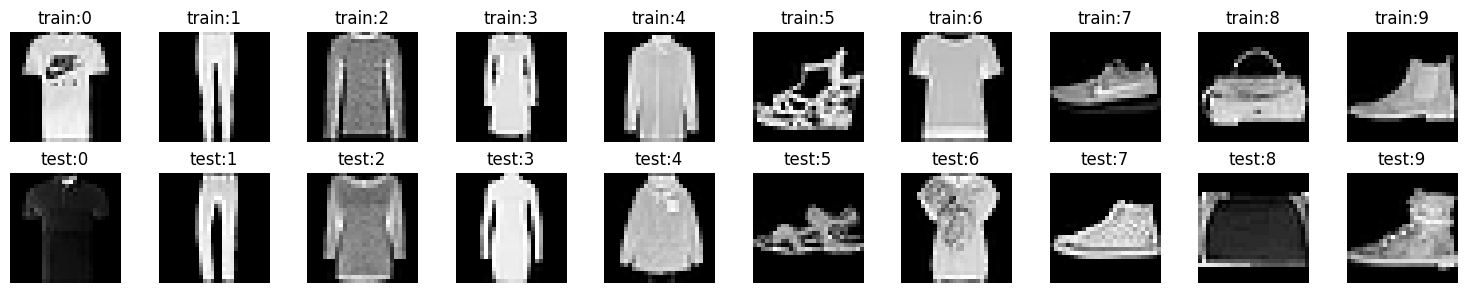

Epoca 001 | Train Loss: 0.8751  Acc: 0.8233  F1_macro: 0.8183  ||  Test Loss: 0.5167   Acc: 0.8111  F1_macro: 0.8058
Epoca 002 | Train Loss: 0.5200  Acc: 0.8490  F1_macro: 0.8457  ||  Test Loss: 0.4512   Acc: 0.8366  F1_macro: 0.8330
Epoca 003 | Train Loss: 0.4577  Acc: 0.8605  F1_macro: 0.8565  ||  Test Loss: 0.4221   Acc: 0.8460  F1_macro: 0.8418
Epoca 004 | Train Loss: 0.4256  Acc: 0.8703  F1_macro: 0.8678  ||  Test Loss: 0.3953   Acc: 0.8576  F1_macro: 0.8547
Epoca 005 | Train Loss: 0.4010  Acc: 0.8779  F1_macro: 0.8771  ||  Test Loss: 0.3774   Acc: 0.8629  F1_macro: 0.8620
Epoca 006 | Train Loss: 0.3871  Acc: 0.8841  F1_macro: 0.8836  ||  Test Loss: 0.3643   Acc: 0.8682  F1_macro: 0.8676
Epoca 007 | Train Loss: 0.3748  Acc: 0.8850  F1_macro: 0.8843  ||  Test Loss: 0.3666   Acc: 0.8639  F1_macro: 0.8630
Epoca 008 | Train Loss: 0.3636  Acc: 0.8856  F1_macro: 0.8855  ||  Test Loss: 0.3636   Acc: 0.8678  F1_macro: 0.8675
Epoca 009 | Train Loss: 0.3568  Acc: 0.8914  F1_macro: 0.8912  |

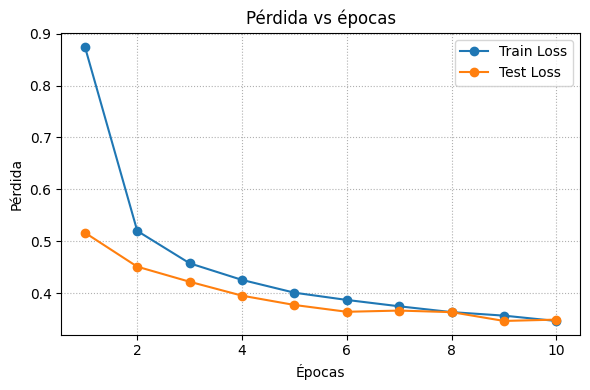

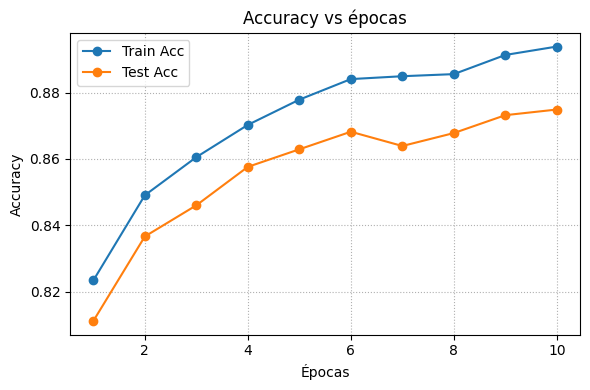

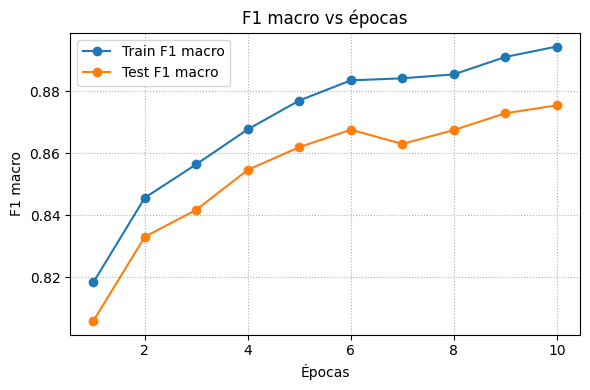

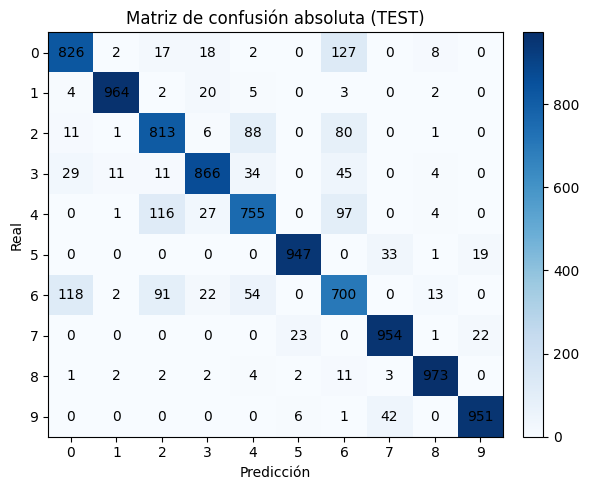

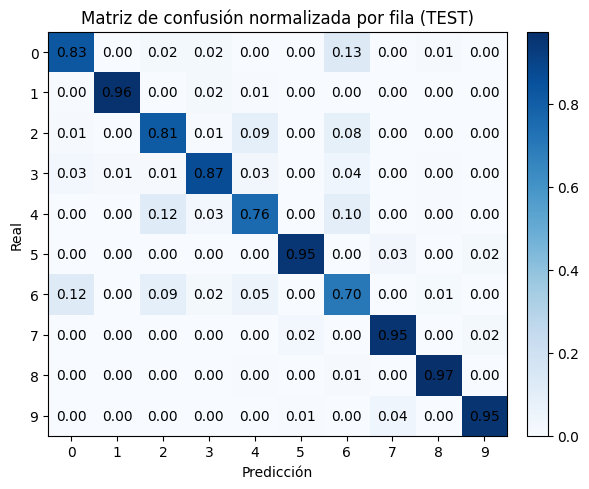

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_set = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

classes = list(range(10))
g = torch.Generator().manual_seed(123)

fig, axes = plt.subplots(2, 10, figsize=(15,3))
for row, ds in enumerate([train_set, test_set]):
    targets = ds.targets
    for c in classes:
        idxs = torch.nonzero(targets==c, as_tuple=False).view(-1)
        ix = idxs[torch.randint(0, idxs.shape[0], (1,), generator=g)].item()
        img, lab = ds[ix]
        axes[row, c].imshow(img.squeeze(0), cmap="gray")
        axes[row, c].set_title(f"{'train' if row==0 else 'test'}:{lab}")
        axes[row, c].axis("off")
plt.tight_layout()
plt.show()


import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),  # Se convierte la matriz 2D que representa a la imagen en un vector de una sola dimensión
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3), # Se aplica dropout con 30% de probabilidad
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3), # Se aplica dropout con 30% de probabilidad
    nn.Linear(64, 10)
).to(device)



import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

epochs = 10
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Historiales para monitorear la evolución por época
train_loss_hist = []      # Pérdida promedio en train por época
test_loss_hist  = []      # Pérdida promedio en test por época
acc_hist_train  = []      # Accuracy en train por época
acc_hist_test   = []      # Accuracy en test por época
f1_hist_train   = []      # F1 macro en train por época
f1_hist_test    = []      # F1 macro en test por época

for ep in range(epochs):
    # Modo entrenamiento:
    model.train()
    running_loss = 0.0     # Acumulador de pérdida en train para promediar al final
    num_batches  = 0

    # Bucle de mini batches sobre el loader de entrenamiento
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)     # Mover batch a CPU o GPU
        logits = model(xb)                        # Forward
        loss = F.cross_entropy(logits, yb)        # Cálculo de pérdida de clasificación

        opt.zero_grad(set_to_none=True)           # Limpia gradientes acumulados
        loss.backward()                           # Backprop
        opt.step()                                # Actualización de pesos con Adam

        running_loss += loss.item()               # Suma de pérdidas para promediar
        num_batches  += 1

    # Promedio de pérdida de entrenamiento para la época actual
    epoch_train_loss = running_loss / max(1, num_batches)
    train_loss_hist.append(epoch_train_loss)

    # Evaluación de métricas en TRAIN para registrar curvas comparables
    model.eval()
    with torch.no_grad():
        preds_train = []
        trues_train = []
        running_loss_te = 0.0
        num_batches_te  = 0

        # Para medir loss en test y métricas en train y test, recorremos ambos dataloaders
        # 1) Métricas en TRAIN
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            preds_train.append(pred.cpu())
            trues_train.append(yb.cpu())

        y_pred_tr = torch.cat(preds_train).numpy()
        y_true_tr = torch.cat(trues_train).numpy()
        acc_tr = accuracy_score(y_true_tr, y_pred_tr)                 # Accuracy train
        f1_tr  = f1_score(y_true_tr, y_pred_tr, average="macro")      # F1 macro train
        acc_hist_train.append(acc_tr)
        f1_hist_train.append(f1_tr)

        # 2) Pérdida y métricas en TEST
        preds_test = []
        trues_test = []
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss_te = F.cross_entropy(logits, yb)                      # Loss por batch en test
            running_loss_te += loss_te.item()
            num_batches_te  += 1
            pred = logits.argmax(dim=1)
            preds_test.append(pred.cpu())
            trues_test.append(yb.cpu())

        epoch_test_loss = running_loss_te / max(1, num_batches_te)     # Loss promedio test
        test_loss_hist.append(epoch_test_loss)

        y_pred_te = torch.cat(preds_test).numpy()
        y_true_te = torch.cat(trues_test).numpy()
        acc_te = accuracy_score(y_true_te, y_pred_te)                  # Accuracy test
        f1_te  = f1_score(y_true_te, y_pred_te, average="macro")       # F1 macro test
        acc_hist_test.append(acc_te)
        f1_hist_test.append(f1_te)

    # Impresión de métricas por época para trazabilidad en consola
    print(f"Epoca {ep+1:03d} | "
          f"Train Loss: {epoch_train_loss:.4f}  Acc: {acc_tr:.4f}  F1_macro: {f1_tr:.4f}  ||  "
          f"Test Loss: {epoch_test_loss:.4f}   Acc: {acc_te:.4f}  F1_macro: {f1_te:.4f}")




# ================================
# Gráficas y matrices de confusión
# ================================

# Rango de épocas para el eje x
ep_range = np.arange(1, epochs + 1)

# 1) Curvas de pérdida por época
plt.figure(figsize=(6,4))
plt.plot(ep_range, train_loss_hist, marker="o", label="Train Loss")
plt.plot(ep_range, test_loss_hist, marker="o", label="Test Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Pérdida vs épocas")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Curvas de accuracy por época
plt.figure(figsize=(6,4))
plt.plot(ep_range, acc_hist_train, marker="o", label="Train Acc")
plt.plot(ep_range, acc_hist_test, marker="o", label="Test Acc")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Accuracy vs épocas")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Curvas de F1 macro por época
plt.figure(figsize=(6,4))
plt.plot(ep_range, f1_hist_train, marker="o", label="Train F1 macro")
plt.plot(ep_range, f1_hist_test, marker="o", label="Test F1 macro")
plt.xlabel("Épocas")
plt.ylabel("F1 macro")
plt.title("F1 macro vs épocas")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Matrices de confusión en TEST: absoluta y normalizada por fila
model.eval()
with torch.no_grad():
    preds_test = []
    trues_test = []
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1)
        preds_test.append(pred.cpu())
        trues_test.append(yb.cpu())
y_pred_te = torch.cat(preds_test).numpy()
y_true_te = torch.cat(trues_test).numpy()

# Etiquetas de clase para el eje
classes = np.unique(np.concatenate([y_true_te, y_pred_te]))
tick_labels = [str(c) for c in classes]

# Función auxiliar para pintar la matriz con anotaciones visibles
def plot_cm(cm, title, fmt_vals, cmap="Blues"):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_yticklabels(tick_labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, fmt_vals(i, j), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Matriz absoluta
cm_abs = confusion_matrix(y_true_te, y_pred_te, labels=classes)
plot_cm(
    cm_abs,
    title="Matriz de confusión absoluta (TEST)",
    fmt_vals=lambda i, j: f"{cm_abs[i, j]:d}"
)

# Matriz normalizada por fila
cm_norm = confusion_matrix(y_true_te, y_pred_te, labels=classes, normalize="true")
plot_cm(
    cm_norm,
    title="Matriz de confusión normalizada por fila (TEST)",
    fmt_vals=lambda i, j: f"{cm_norm[i, j]:.2f}"
)
